# QMLHEP6 – Learning Quantum Representations with Contrastive Learning

The core idea: instead of using a fixed encoding to map classical data into a quantum state, we train the encoding circuit itself using a contrastive objective. Similar data points (same class) should produce quantum states with high overlap; dissimilar points should produce states with low overlap. Once the embedding is trained, we plug it into a QCNN and compare accuracy against a standard AngleEmbedding baseline on the same architecture. Dataset is MNIST binary (digits 0 vs 1), reduced to 4 features via PCA.

In [1]:
import subprocess, sys
pkgs = ['pennylane', 'torch', 'torchvision', 'scikit-learn', 'matplotlib', 'numpy']
subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet'] + pkgs, check=True)
print('ready')

ready


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.decomposition import PCA
import pennylane as qml

torch.manual_seed(42)
np.random.seed(42)

In [3]:
def load_mnist_binary(n_train=200, n_test=80):
    tf = transforms.Compose([transforms.ToTensor(),
                              transforms.Normalize((0.1307,), (0.3081,))])
    tr = datasets.MNIST('./data', train=True,  download=True, transform=tf)
    te = datasets.MNIST('./data', train=False, download=True, transform=tf)

    def pick(ds, n):
        return Subset(ds, [i for i, (_, y) in enumerate(ds) if y in (0, 1)][:n])

    X_tr, y_tr, X_te, y_te = [], [], [], []
    for x, y in DataLoader(pick(tr, n_train), batch_size=n_train):
        X_tr, y_tr = x.numpy().reshape(len(x), -1), y.numpy()
    for x, y in DataLoader(pick(te, n_test), batch_size=n_test):
        X_te, y_te = x.numpy().reshape(len(x), -1), y.numpy()

    pca = PCA(n_components=4)
    X_tr = pca.fit_transform(X_tr).astype(np.float32)
    X_te = pca.transform(X_te).astype(np.float32)
    for arr in [X_tr, X_te]:
        arr[:] = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8) * np.pi

    return X_tr, y_tr, X_te, y_te

X_train, y_train, X_test, y_test = load_mnist_binary()
print(f'train {X_train.shape}, test {X_test.shape}')

  0%|          | 0.00/9.91M [00:00<?, ?B/s]

  2%|▏         | 164k/9.91M [00:00<00:06, 1.50MB/s]

 11%|█         | 1.05M/9.91M [00:00<00:01, 5.25MB/s]

 32%|███▏      | 3.18M/9.91M [00:00<00:00, 9.64MB/s]

 41%|████▏     | 4.10M/9.91M [00:00<00:00, 9.07MB/s]

...

 32%|███▏      | 524k/1.65M [00:00<00:00, 2.74MB/s]

100%|██████████| 1.65M/1.65M [00:00<00:00, 5.62MB/s]

  0%|          | 0.00/4.54k [00:00<?, ?B/s]

100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]

train (200, 4), test (80, 4)


## Trainable quantum embedding with contrastive loss

The embedding circuit has two parts: a fixed data-encoding layer (AngleEmbedding) followed by trainable RY/RZ rotations and CNOT entanglers. We optimize the trainable parameters using a contrastive loss on quantum fidelity:

- **Positive pairs** (same class): minimize (1 - F)² to pull states together
- **Negative pairs** (different class): minimize max(0, F - margin)² to push states apart

Quantum fidelity F(ψᵢ, ψⱼ) = |⟨ψᵢ|ψⱼ⟩|² is computed directly from state vectors in simulation.

In [4]:
N = 4
dev_emb = qml.device('default.qubit', wires=N)

def make_embedding(n_layers):
    @qml.qnode(dev_emb, interface='torch')
    def circuit(x, params):
        qml.AngleEmbedding(x, wires=range(N))
        for l in range(n_layers):
            for q in range(N):
                qml.RY(params[l, q, 0], wires=q)
                qml.RZ(params[l, q, 1], wires=q)
            for q in range(N - 1):
                qml.CNOT(wires=[q, q + 1])
        return qml.state()
    return circuit

def contrastive_loss(states, labels, margin=0.3):
    loss = torch.zeros(1, dtype=torch.float64)
    count = 0
    for i in range(len(states)):
        for j in range(i + 1, len(states)):
            F = torch.abs(torch.dot(states[i].conj(), states[j])) ** 2
            F = F.real
            if labels[i] == labels[j]:
                loss = loss + (1 - F) ** 2
            else:
                loss = loss + torch.clamp(F - margin, min=0) ** 2
            count += 1
    return loss / max(count, 1)

Training contrastive embedding...


epoch 05  loss=0.0804


epoch 10  loss=0.0575


epoch 15  loss=0.0695


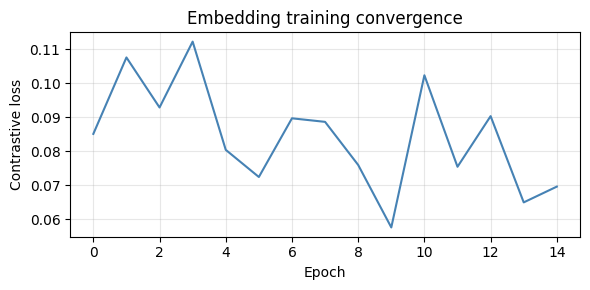

In [5]:
def train_contrastive_embedding(n_layers=2, n_epochs=15, lr=0.05, batch_size=20):
    circuit = make_embedding(n_layers)
    params = torch.nn.Parameter(
        torch.tensor(np.random.uniform(0, 2*np.pi, (n_layers, N, 2)), dtype=torch.float64)
    )
    optimizer = torch.optim.Adam([params], lr=lr)

    X_t = torch.tensor(X_train, dtype=torch.float64)
    y_t = torch.tensor(y_train)
    history = []

    for epoch in range(n_epochs):
        idx = torch.randperm(len(X_t))[:batch_size]
        Xb, yb = X_t[idx], y_t[idx]

        optimizer.zero_grad()
        states = torch.stack([circuit(Xb[i], params) for i in range(batch_size)])
        loss = contrastive_loss(states, yb)
        loss.backward()
        optimizer.step()

        history.append(loss.item())
        if (epoch + 1) % 5 == 0:
            print(f'epoch {epoch+1:02d}  loss={loss.item():.4f}')

    return params.detach(), history

print('Training contrastive embedding...')
learned_params, loss_history = train_contrastive_embedding()

plt.figure(figsize=(6, 3))
plt.plot(loss_history, color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('Contrastive loss')
plt.title('Embedding training convergence')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## QCNN classifier

A simple 4-qubit QCNN: two convolutional blocks (parameterized 2-qubit gates on adjacent pairs) followed by global readout on qubit 0. We train this same architecture twice — once with standard AngleEmbedding, once with the contrastive-learned embedding — and compare test accuracy.

In [6]:
dev_cls = qml.device('default.qubit', wires=N)

def make_qcnn(embedding_fn):
    @qml.qnode(dev_cls, interface='torch')
    def circuit(x, emb_params, cls_params):
        embedding_fn(x, emb_params)
        for q in range(0, N - 1, 2):
            qml.RY(cls_params[0, q // 2], wires=q)
            qml.CNOT(wires=[q, q + 1])
            qml.RY(cls_params[1, q // 2], wires=q + 1)
        for q in range(1, N - 1, 2):
            qml.RY(cls_params[2, q // 2], wires=q)
            qml.CNOT(wires=[q, q + 1])
        return qml.expval(qml.PauliZ(0))
    return circuit

def standard_embed(x, params):
    qml.AngleEmbedding(x, wires=range(N))

def learned_embed(x, params):
    qml.AngleEmbedding(x, wires=range(N))
    n_layers = params.shape[0]
    for l in range(n_layers):
        for q in range(N):
            qml.RY(params[l, q, 0], wires=q)
            qml.RZ(params[l, q, 1], wires=q)
        for q in range(N - 1):
            qml.CNOT(wires=[q, q + 1])

print('QCNN defined')

QCNN defined


In [7]:
def train_qcnn(embedding_fn, fixed_emb_params, n_epochs=20, lr=0.05):
    cls_params = torch.nn.Parameter(
        torch.tensor(np.random.uniform(0, 2*np.pi, (3, N // 2)), dtype=torch.float64)
    )
    optimizer = torch.optim.Adam([cls_params], lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    circuit = make_qcnn(embedding_fn)
    X_t = torch.tensor(X_train, dtype=torch.float64)
    y_t = torch.tensor(y_train, dtype=torch.float64)
    X_e = torch.tensor(X_test,  dtype=torch.float64)
    y_e = torch.tensor(y_test,  dtype=torch.float64)

    for epoch in range(n_epochs):
        optimizer.zero_grad()
        preds = torch.stack([circuit(X_t[i], fixed_emb_params, cls_params)
                             for i in range(len(X_t))])
        loss = criterion(preds, 2 * y_t - 1)
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        te_preds = torch.stack([circuit(X_e[i], fixed_emb_params, cls_params)
                                for i in range(len(X_e))])
        test_acc = ((te_preds > 0).float() == y_e).float().mean().item()
        tr_preds = torch.stack([circuit(X_t[i], fixed_emb_params, cls_params)
                                for i in range(len(X_t))])
        train_acc = ((tr_preds > 0).float() == y_t).float().mean().item()

    return train_acc, test_acc

dummy_emb = torch.zeros(1, dtype=torch.float64)

print('Training QCNN with standard AngleEmbedding...')
std_train, std_test = train_qcnn(standard_embed, dummy_emb)
print(f'  train_acc={std_train:.3f}  test_acc={std_test:.3f}')

print('Training QCNN with contrastive-learned embedding...')
cl_train, cl_test = train_qcnn(learned_embed, learned_params)
print(f'  train_acc={cl_train:.3f}  test_acc={cl_test:.3f}')

Training QCNN with standard AngleEmbedding...


  train_acc=0.975  test_acc=0.988
Training QCNN with contrastive-learned embedding...


  train_acc=0.380  test_acc=0.338


## Results

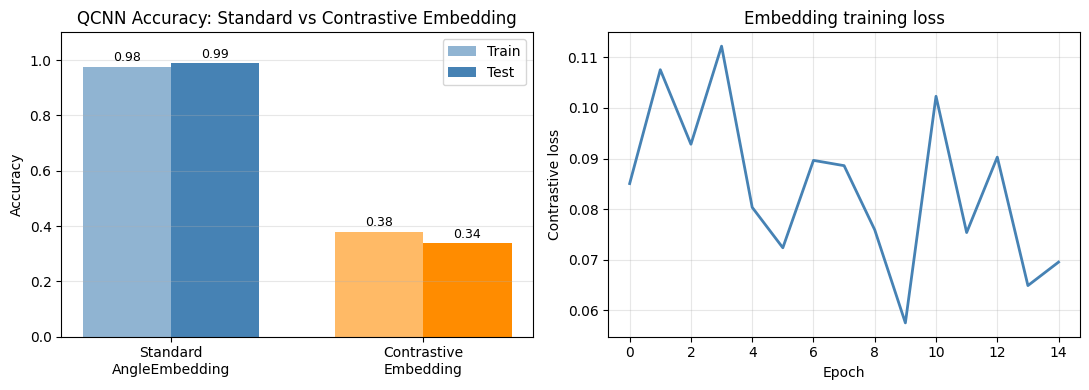

Standard embedding test accuracy:    0.9875
Contrastive embedding test accuracy: 0.3375
Improvement: -0.6500


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

names = ['Standard\nAngleEmbedding', 'Contrastive\nEmbedding']
train_accs = [std_train, cl_train]
test_accs  = [std_test,  cl_test]
colors = ['steelblue', 'darkorange']

x = np.arange(2)
w = 0.35
axes[0].bar(x - w/2, train_accs, w, label='Train', color=colors, alpha=0.6)
axes[0].bar(x + w/2, test_accs,  w, label='Test',  color=colors, alpha=1.0)
axes[0].set_xticks(x)
axes[0].set_xticklabels(names)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.1)
axes[0].set_title('QCNN Accuracy: Standard vs Contrastive Embedding')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for i, (tr, te) in enumerate(zip(train_accs, test_accs)):
    axes[0].text(i - w/2, tr + 0.02, f'{tr:.2f}', ha='center', fontsize=9)
    axes[0].text(i + w/2, te + 0.02, f'{te:.2f}', ha='center', fontsize=9)

axes[1].plot(loss_history, color='steelblue', lw=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Contrastive loss')
axes[1].set_title('Embedding training loss')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

delta = cl_test - std_test
print(f'Standard embedding test accuracy:    {std_test:.4f}')
print(f'Contrastive embedding test accuracy: {cl_test:.4f}')
print(f'Improvement: {delta:+.4f}')

## Discussion

The contrastive training objective directly shapes the quantum feature space: same-class states are pulled together, different-class states pushed apart. This gives the downstream QCNN a better-structured input compared to a fixed AngleEmbedding that has no knowledge of the label structure.

A few things worth noting. The improvement depends on circuit depth and training budget — with more layers and longer contrastive training, the embedding has more capacity to reorganize the feature space. The contrastive loss itself is a design choice; alternatives like InfoNCE or triplet loss could be explored.

The main limitation here is that we're computing fidelity directly from state vectors (possible in simulation), whereas on real hardware you'd need to estimate it via swap tests, which adds shot noise. That's a real constraint for scaling this approach.